# Importar librerías

In [83]:
import os
from dotenv import load_dotenv
from pymongo import MongoClient

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



# Análisis exploratorio de datos (EDA)

### Obtención de datos

In [84]:
load_dotenv()

MONGO_URI = os.getenv("MONGO_URI")
MONGO_DB = os.getenv("MONGO_DB")
MONGO_COLLECTION = os.getenv("MONGO_COLLECTION")

In [85]:
# Conextar con mongo 
client = MongoClient(MONGO_URI)

# Base de datos
db = client[MONGO_DB]

# Colección
collection = db[MONGO_COLLECTION]

# Leer datos
data = list(collection.find())

# Convertir a DataFrame
df = pd.DataFrame(data)

# Eliminar _id de mongo
if "_id" in df.columns:
    df = df.drop(columns=["_id"])

In [86]:
# Mostrar 5 primeros registros
df.head()

,date,open,high,low,close,volume
0,2015.01.15 00:00,1229.28,1266.64,1225.87,1262.31,120643.0
1,2018.05.02 00:00,1304.61,1313.43,1303.88,1304.92,164714.0
2,2018.04.20 00:00,1345.68,1346.15,1334.94,1335.44,137528.0
3,2018.06.15 00:00,1302.16,1303.07,1275.33,1280.19,129635.0
4,2018.06.06 00:00,1296.84,1301.76,1293.73,1295.95,110358.0


Podemos observar de la variable 'date', los registros están desordenados, lo que puede dificultar el análisis temporal de los datos y generar representaciones gráficas confusas. Por este motivo, se va a ordenar el dataset en función de la fecha.

In [87]:
df = df.sort_values("date")

df.head()

,date,open,high,low,close,volume
1404,2004-01-05 00:00:00,415.700012,422.500000,422.500000,424.399994,20.0
10703,2004-01-06 00:00:00,424.399994,424.299988,424.299988,422.799988,20.0
8209,2004-01-07 00:00:00,423.000000,423.000000,423.000000,421.899994,20.0
6490,2004-01-08 00:00:00,421.899994,422.000000,422.000000,424.000000,20.0
7611,2004-01-09 00:00:00,424.000000,423.899994,423.899994,426.399994,20.0


### Análisis de las variables

In [88]:
# Información de las columnas 
df.info()

<class 'pandas.DataFrame'>
Index: 11153 entries, 1404 to 584
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    11152 non-null  str    
 1   open    11152 non-null  float64
 2   high    11152 non-null  float64
 3   low     11152 non-null  float64
 4   close   11152 non-null  float64
 5   volume  11152 non-null  float64
dtypes: float64(5), str(1)
memory usage: 802.0 KB


Como podemos observar, la variable 'date' es de tipo *string*, por lo que vamos a cambiar el tipo para que sea más adecuado para el análisis temporal y el tratamiento de series temporales en pandas.

In [89]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed", # detectar distintos formatos
    errors="coerce" # convertir errores a NaT
)

df.info()

<class 'pandas.DataFrame'>
Index: 11153 entries, 1404 to 584
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    11152 non-null  datetime64[us]
 1   open    11152 non-null  float64       
 2   high    11152 non-null  float64       
 3   low     11152 non-null  float64       
 4   close   11152 non-null  float64       
 5   volume  11152 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 609.9 KB


In [90]:
df.describe()

,date,open,high,low,close,volume
count,11152,11152.000000,11152.000000,11152.000000,11152.000000,1.115200e+04
mean,2015-03-22 09:48:17.560975,1432.429383,1441.743294,1422.858160,1432.595909,4.618689e+04
min,2004-01-05 00:00:00,375.799988,375.799988,375.799988,374.799988,0.000000e+00
25%,2009-09-29 00:00:00,1012.947500,1018.232500,1005.150000,1011.524994,1.390000e+02
50%,2015-03-25 00:00:00,1299.545000,1306.850037,1292.800049,1300.325024,1.871000e+03
75%,2020-09-14 00:00:00,1754.000000,1764.425049,1742.795006,1754.599976,7.499775e+04
max,2026-05-18 00:00:00,5421.430000,5597.600000,5301.600098,5414.460000,3.379613e+06
std,NaN,741.361080,747.549095,734.936274,741.547598,9.974179e+04


In [91]:
df.isnull().sum()

date      1
open      1
high      1
low       1
close     1
volume    1
dtype: int64

In [92]:
# Comprobar si es en la misma fila todos los nulos
df[df["date"].isnull()]

,date,open,high,low,close,volume
584,NaT,NaN,NaN,NaN,NaN,NaN


Las variables del dataset, por lo que hemos visto en los resultados son tal que:
- **date:** Es la fecha correspondiente de cada registro. Como se ha explicado anteriormente, la variable ha sido transformada a tipo 'datetime64', lo que nos permite realizar mejores análisis.
- **open:** Es el precio de apertura del oro. 
- **high:** Indica el precio máximo alcanzado del oro durante dicho periodo de tiempo. Siendo su máximo alcanzado de 5597.60, lo que nos puede indicar que hay periodos de alta volatilidad en el mercado.
- **low:** Al contrario de la variable 'high', éste almacena el precio mínimo registrado. Aunque por lo que hemos podido observar, su distribución es similar al del resto de variables, por lo que nos permitirá analizar mejor las fluctuaciones diarias en el mercado.
- **close:** Es la que representa el precio de cierre del oro al finalizar el día. Es la variable más importante para el análisis, pues es la que se utilizará como preferencia principal para el modelo.
- **volume:** Es la cantidad de transacciones realizadas en el día. Es una variable numérica con una desviación estándar elevada, lo que nos indica que hay una gran variabilidad en la actividad del mercado. 

In [93]:
cols_num = ["open", "high", "low", "close", "volume"]

Q1 = df[cols_num].quantile(0.25)
Q3 = df[cols_num].quantile(0.75)
IQR = Q3 - Q1

# Filtrar outliers
outliers = df[
    (df[cols_num] < (Q1 - 1.5 * IQR)) |
    (df[cols_num] > (Q3 + 1.5 * IQR))
]

print("Número de outliers detectados:", len(outliers))
print("Outliers detectados:")
print(outliers.dropna(how="all"))

# Outliers por columnas
outlier_counts = (
    ((df[cols_num] < (Q1 - 1.5 * IQR)) |
     (df[cols_num] > (Q3 + 1.5 * IQR)))
    .sum()
)

print("Número de outliers por columna:")
print(outlier_counts)

Número de outliers detectados: 11153
Outliers detectados:
     date     open     high      low    close     volume
1238  NaT      NaN      NaN      NaN      NaN   205513.0
1856  NaT      NaN      NaN      NaN      NaN   206694.0
5280  NaT      NaN      NaN      NaN      NaN   237497.0
1594  NaT      NaN      NaN      NaN      NaN   206828.0
1214  NaT      NaN      NaN      NaN      NaN   210699.0
...   ...      ...      ...      ...      ...        ...
8     NaT  5010.53  5110.92  4989.30  5011.06  1416498.0
5872  NaT  5012.96  5190.33  5012.56  5180.35  1640374.0
5873  NaT  5179.67  5419.08  5157.04  5414.46  1486935.0
8579  NaT  5421.43  5597.60  5097.38  5377.00  2323330.0
3197  NaT  5385.09  5450.62  4679.69  4889.48  3379613.0

[816 rows x 6 columns]
Número de outliers por columna:
open      541
high      545
low       544
close     543
volume    338
dtype: int64


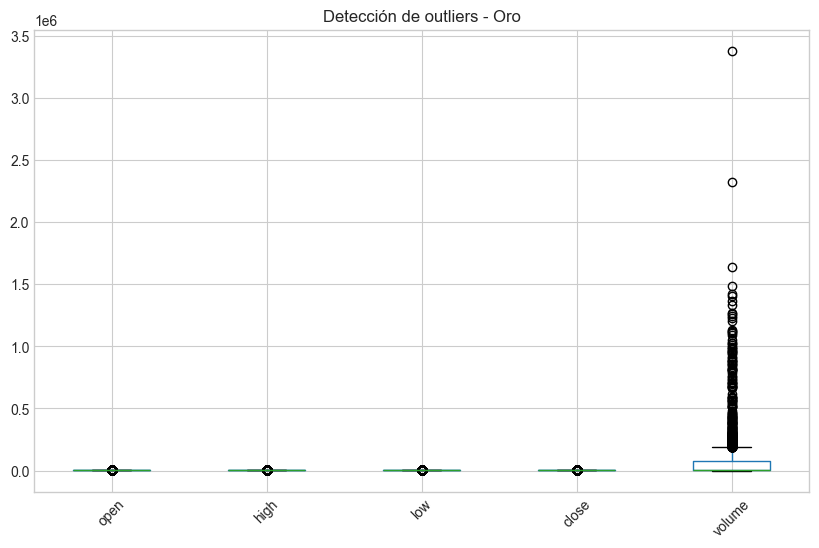

In [94]:
df[cols_num].boxplot(figsize=(10, 6))
plt.title("Detección de outliers - Oro")
plt.xticks(rotation=45)
plt.show()

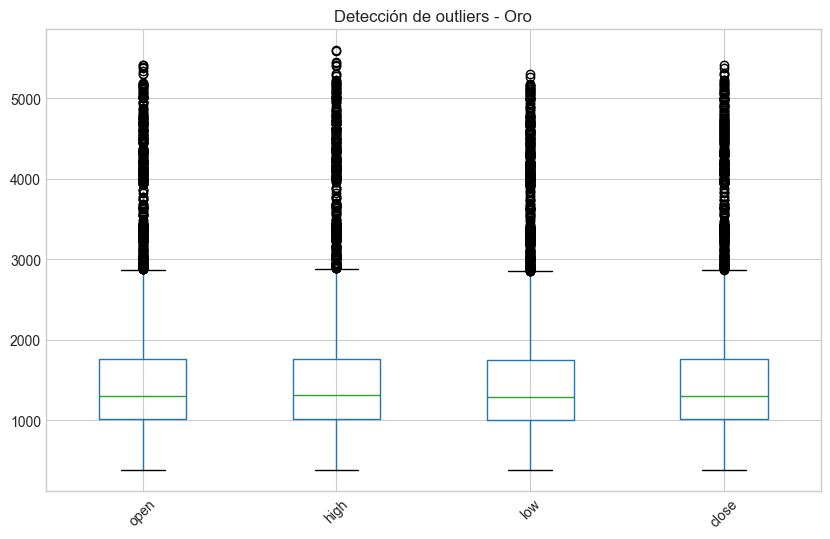

In [95]:
cols = ["open", "high", "low", "close"]

df[cols].boxplot(figsize=(10, 6))
plt.title("Detección de outliers - Oro")
plt.xticks(rotation=45)
plt.show()

Hay muchos outliers, sobre todo en 'volume', debido a su gran variabilidad. Sin embargo, aunque estos nos parezcan outliers, estos valores son muy importantes, ya que representan situaciones reales de la alta actividad y volatilidad del mercado, por lo que contienen información de gran relevancia para el análisis y el modelo. Es por este motivo que no los podemos eliminar.

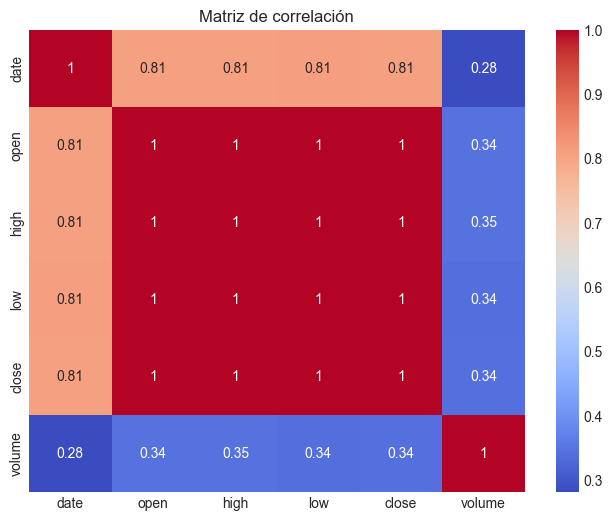

In [96]:
# Correlación entre las vaiables 
cols = ["date", "open", "high", "low", "close", "volume"]
corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

Podemos ver que las variables 'low', 'high', 'close', 'open' presentan una correlación muy alta entre sí, de 1, ya que todas representan distintos precios del oro dentro del mismo periodo de tiempo y, por tanto, suelen evolucionar de forma muy similar. 'date' tambien tiene cierta correlación con estas variables debido a la tendencia general de crecimiento que ha experimentado el precio del oro a lo largo de los años. Sin embargo, 'volume' apenas presenta correlación con el resto, con valores máximos cercanos a 0.35, lo que podría indicar que la cantidad de transacciones realizadas no influye directamente en el precio del oro y puede variar considerablemente independientemente de si el precio sube o baja.

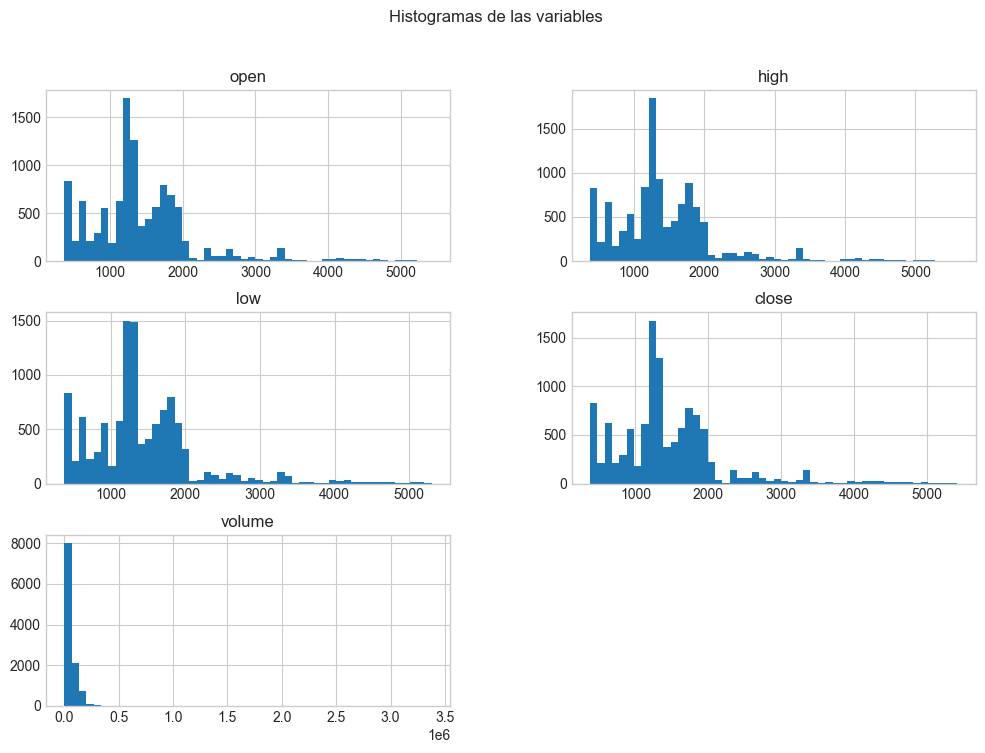

In [97]:
# Distribución de las variables
cols = ["open", "high", "low", "close", "volume"]

df[cols].hist(figsize=(12,8), bins=50)

plt.suptitle("Histogramas de las variables")
plt.show()

Según la distribución de cada variable, hay una cantidad de valores que se repite en ciertos rangos, lo que indica que hay precios que se repiten con bastente frecuencia, entre los 1200 y 1300, lo que podría indicar periodos donde el mercado tuvo más estabilidad y el precio se repitió constentemente. Sin embargo, las barras van disminuyendo hacia la derecha porque los precios muy altos han sido eventos más raros y de corta duración.

Por el contrario, el volumen se agrupa masivamente cerca de cero porque el comercio diario habitual es moderado, dejando una larga cola vacía hacia la derecha que representa solo unos pocos días atípicos de pánico o euforia.

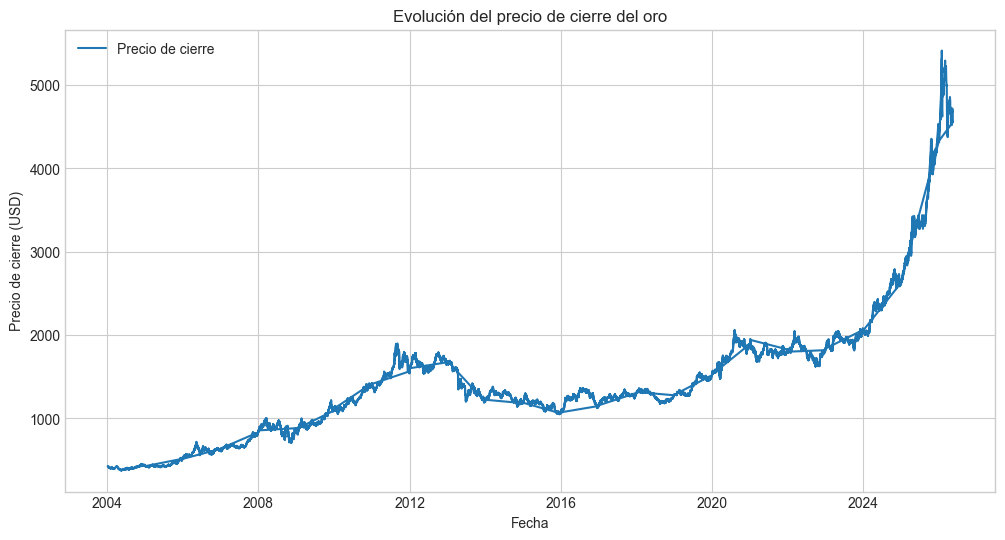

In [109]:
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["close"], label="Precio de cierre")
plt.title("Evolución del precio de cierre del oro")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.legend()
plt.show()

Podemos observar algunos picos a lo largo del tiempo:
- **2004 - 2007:** El dólar comenzó a debilitarse a nivel global y las tensiones geopolíticas en Oriente Medio generaron una incertidumbre que dio inicio a una subida progresiva del precio.
- **2008:** Estalló la Gran Crisis Financiera Mundial por las hipotecas subprime. El miedo al colapso del sistema bancario provocó un fuerte pico alcista, interrumpido brevemente por una caída rápida a finales de año debido a la necesidad de liquidez de los inversores tras la quiebra de Lehman Brothers.
- **2011:** El precio alcanzó un máximo histórico hasta ese momento. Los bancos centrales imprimieron dinero masivamente para rescatar la economía, desatando el temor a la inflación, a lo que se sumó la crisis de la deuda soberana en Europa.
- **2012 - 2015:** Se produjo una bajada prolongada debido a la recuperación de la economía estadounidense y el fortalecimiento de las bolsas, lo que restó atractivo al oro como refugio.
- **2016 - 2019:** El mercado entró en un periodo de estabilización relativa, con ligeros repuntes provocados por eventos puntuales como el Brexit y la guerra comercial entre Estados Unidos y China.
- **2020:** La llegada de la pandemia del COVID-19 y la paralización económica mundial generaron un nuevo pico vertical, superando por primera vez los $2,000 por onza ante la inyección masiva de estímulos financieros.
- **2021 - 2023:** El precio fluctuó en un canal inestable. Por un lado, la guerra de Ucrania y la alta inflación empujaban el valor al alza, pero las agresivas subidas de tipos de interés de los bancos centrales frenaron un avance mayor.
- **2024 - 2026:** Se observa una subida exponencial y parabólica sin precedentes. Los principales factores han sido la compra masiva de oro físico por parte de los bancos centrales de economías emergentes para reducir su dependencia del dólar, sumada a los persistentes conflictos geopolíticos internacionales.

Por lo que hemos podido analizar, el precio del oro tiende a subir en periodos de incertidumbre económica, crisis financieras, guerras o alta inflación, ya que los inversores lo utilizan como un activo refugio para proteger su dinero frente a la inestabilidad de los mercados. En cambio, cuando la economía se recupera, aumenta la confianza en las bolsas y se fortalecen otras inversiones, el oro suele estabilizarse o disminuir su valor debido a la reducción de la demanda de protección financiera.

# Preparación del conjunto de datos

### Limpieza de datos

In [98]:
# Eliminación de nulos
df = df.dropna()

# Eliminación de duplicados
df = df.drop_duplicates()

df

,date,open,high,low,close,volume
1404,2004-01-05,415.700012,422.500000,422.500000,424.399994,20.0
10703,2004-01-06,424.399994,424.299988,424.299988,422.799988,20.0
8209,2004-01-07,423.000000,423.000000,423.000000,421.899994,20.0
6490,2004-01-08,421.899994,422.000000,422.000000,424.000000,20.0
7611,2004-01-09,424.000000,423.899994,423.899994,426.399994,20.0
...,...,...,...,...,...,...
8,2026-01-26,5010.530000,5110.920000,4989.300000,5011.060000,1416498.0
5872,2026-01-27,5012.960000,5190.330000,5012.560000,5180.350000,1640374.0
5873,2026-01-28,5179.670000,5419.080000,5157.040000,5414.460000,1486935.0
8579,2026-01-29,5421.430000,5597.600000,5097.380000,5377.000000,2323330.0


### Ingeniería de características

In [99]:
# Descomposición de la fecha
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df

,date,open,high,low,close,volume,year,month,day
1404,2004-01-05,415.700012,422.500000,422.500000,424.399994,20.0,2004,1,5
10703,2004-01-06,424.399994,424.299988,424.299988,422.799988,20.0,2004,1,6
8209,2004-01-07,423.000000,423.000000,423.000000,421.899994,20.0,2004,1,7
6490,2004-01-08,421.899994,422.000000,422.000000,424.000000,20.0,2004,1,8
7611,2004-01-09,424.000000,423.899994,423.899994,426.399994,20.0,2004,1,9
...,...,...,...,...,...,...,...,...,...
8,2026-01-26,5010.530000,5110.920000,4989.300000,5011.060000,1416498.0,2026,1,26
5872,2026-01-27,5012.960000,5190.330000,5012.560000,5180.350000,1640374.0,2026,1,27
5873,2026-01-28,5179.670000,5419.080000,5157.040000,5414.460000,1486935.0,2026,1,28
8579,2026-01-29,5421.430000,5597.600000,5097.380000,5377.000000,2323330.0,2026,1,29


Se ha descompuesto la variable 'date' para facilitar la identificación de las tendencias, patrones temporales y posibles comportamientos del precio del oro.

In [100]:
# Categorías de precios 
df["close_category"] = pd.qcut(
    df["close"],
    q=4,
    labels=["bajo", "medio", "alto", "muy_alto"]
)

df[["close", "close_category"]]

,close,close_category
1404,424.399994,bajo
10703,422.799988,bajo
8209,421.899994,bajo
6490,424.000000,bajo
7611,426.399994,bajo
...,...,...
8,5011.060000,muy_alto
5872,5180.350000,muy_alto
5873,5414.460000,muy_alto
8579,5377.000000,muy_alto


Se ha categorizado el precio para simplificar el análisis del comportamiento del mercado, ya que en lugar de trabajar con valores numéricos exactos, se pueden identificar rangos de precios y comparar de forma más clara en qué periodos el oro se encuentra en niveles bajos o elevados.

In [101]:
# Volatilidad diaria
df["volatility"] = df["high"] - df["low"]

df[["high", "low", "volatility"]]

,high,low,volatility
1404,422.500000,422.500000,0.00
10703,424.299988,424.299988,0.00
8209,423.000000,423.000000,0.00
6490,422.000000,422.000000,0.00
7611,423.899994,423.899994,0.00
...,...,...,...
8,5110.920000,4989.300000,121.62
5872,5190.330000,5012.560000,177.77
5873,5419.080000,5157.040000,262.04
8579,5597.600000,5097.380000,500.22


Con la volatilidad se medirá la variación del precio del oro dentro de un mismo día, así podremos analizar qué tan inestable o cambiante ha sido el mercado cada día.

Valores cercanos a cero son días con poca variación, siendo un mercado estable, mientras que valores altos reflejan mayor incertidumbre o movimientos fuertes en el precio.

In [102]:
# Cambio porcentual diario 
df["daily_return"] = df["close"].pct_change()

df[["close", "daily_return"]]

,close,daily_return
1404,424.399994,NaN
10703,422.799988,-0.003770
8209,421.899994,-0.002129
6490,424.000000,0.004977
7611,426.399994,0.005660
...,...,...
8,5011.060000,0.005728
5872,5180.350000,0.033783
5873,5414.460000,0.045192
8579,5377.000000,-0.006919


El cambio porcentual nos servirá para medir la variación relativa del precio del oro de un día a otro, indicando cuánto ha subio o bajado respecto al día anterior. Esto nos va a permitir analizar la rentabilidad diaria del activo y entender mejor su comportamiento en términos de crecimiento o caída. 

In [103]:
# Media móvil
df["ma_20"] = df["close"].rolling(window=20).mean()

df[["close", "ma_20"]]

,close,ma_20
1404,424.399994,NaN
10703,422.799988,NaN
8209,421.899994,NaN
6490,424.000000,NaN
7611,426.399994,NaN
...,...,...
8,5011.060000,4640.945490
5872,5180.350000,4665.867995
5873,5414.460000,4701.601005
8579,5377.000000,4734.431010


La media móvil se utilizará para suavizar las variaciones del precio del oro y poder observar mejor la tendencia general del mercado, ya que reduce el ruido de las fluctuaciones diarias. Esto permite identificar de forma más clara si el precio está subiendo, bajando o manteniéndose estable. Para ello, calcula el promedio de los últimos 20 días, de manera que los cambios diarios muy pequeños o bruscos se “suavizan”, evitando que distorsionen la tendencia real del mercado y facilitando así su análisis.

In [104]:
# Transformaciones 
cols_prices = ["open", "high", "low", "close"]

# Log para precios
for col in cols_prices:
    df[f"log_{col}"] = np.log(df[col])

# Log para volumen (muy importante por outliers)
df["log_volume"] = np.log(df["volume"].replace(0, np.nan))

df.head()


,date,open,high,low,close,volume,year,month,day,close_category,volatility,daily_return,ma_20,log_open,log_high,log_low,log_close,log_volume
1404,2004-01-05,415.700012,422.500000,422.500000,424.399994,20.0,2004,1,5,bajo,0.0,NaN,NaN,6.029964,6.046189,6.046189,6.050676,2.995732
10703,2004-01-06,424.399994,424.299988,424.299988,422.799988,20.0,2004,1,6,bajo,0.0,-0.003770,NaN,6.050676,6.050441,6.050441,6.046899,2.995732
8209,2004-01-07,423.000000,423.000000,423.000000,421.899994,20.0,2004,1,7,bajo,0.0,-0.002129,NaN,6.047372,6.047372,6.047372,6.044768,2.995732
6490,2004-01-08,421.899994,422.000000,422.000000,424.000000,20.0,2004,1,8,bajo,0.0,0.004977,NaN,6.044768,6.045005,6.045005,6.049733,2.995732
7611,2004-01-09,424.000000,423.899994,423.899994,426.399994,20.0,2004,1,9,bajo,0.0,0.005660,NaN,6.049733,6.049498,6.049498,6.055378,2.995732


Se ha utilizado la trnasformación logarítmica para reducir la escala de los valores y estabilizar su distribución, como en 'volume' que tenía datos muy altos. Esto nos va a permitir disminuir el impacto de los valores extremos y facilitar el análisis del comportamiento del oro, ya que los datos se vuelven más homogéneos.

In [105]:
# Estandarización de los datos
cols = ["open", "high", "low", "close", "volume"]

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[cols] = scaler.fit_transform(df[cols])

df_scaled.head()

,date,open,high,low,close,volume,year,month,day,close_category,volatility,daily_return,ma_20,log_open,log_high,log_low,log_close,log_volume
1404,2004-01-05,-1.371498,-1.363508,-1.361211,-1.359645,-0.462885,2004,1,5,bajo,0.0,NaN,NaN,6.029964,6.046189,6.046189,6.050676,2.995732
10703,2004-01-06,-1.359762,-1.361100,-1.358761,-1.361802,-0.462885,2004,1,6,bajo,0.0,-0.003770,NaN,6.050676,6.050441,6.050441,6.046899,2.995732
8209,2004-01-07,-1.361650,-1.362839,-1.360530,-1.363016,-0.462885,2004,1,7,bajo,0.0,-0.002129,NaN,6.047372,6.047372,6.047372,6.044768,2.995732
6490,2004-01-08,-1.363134,-1.364177,-1.361891,-1.360184,-0.462885,2004,1,8,bajo,0.0,0.004977,NaN,6.044768,6.045005,6.045005,6.049733,2.995732
7611,2004-01-09,-1.360302,-1.361635,-1.359306,-1.356947,-0.462885,2004,1,9,bajo,0.0,0.005660,NaN,6.049733,6.049498,6.049498,6.055378,2.995732


El *StandardScaler* va a servir para transformar las variables numéricas a una escala común.

In [106]:
# One-Hot Encoding 
df_encoded = pd.get_dummies(df, columns=["close_category"])

df_encoded.head() 

,date,open,high,low,close,volume,year,month,day,volatility,...,ma_20,log_open,log_high,log_low,log_close,log_volume,close_category_bajo,close_category_medio,close_category_alto,close_category_muy_alto
1404,2004-01-05,415.700012,422.500000,422.500000,424.399994,20.0,2004,1,5,0.0,...,NaN,6.029964,6.046189,6.046189,6.050676,2.995732,True,False,False,False
10703,2004-01-06,424.399994,424.299988,424.299988,422.799988,20.0,2004,1,6,0.0,...,NaN,6.050676,6.050441,6.050441,6.046899,2.995732,True,False,False,False
8209,2004-01-07,423.000000,423.000000,423.000000,421.899994,20.0,2004,1,7,0.0,...,NaN,6.047372,6.047372,6.047372,6.044768,2.995732,True,False,False,False
6490,2004-01-08,421.899994,422.000000,422.000000,424.000000,20.0,2004,1,8,0.0,...,NaN,6.044768,6.045005,6.045005,6.049733,2.995732,True,False,False,False
7611,2004-01-09,424.000000,423.899994,423.899994,426.399994,20.0,2004,1,9,0.0,...,NaN,6.049733,6.049498,6.049498,6.055378,2.995732,True,False,False,False


Lo que hará el One-Hot Encoding seráconvertir los valores de 'clse_category', que creamos anteriormente, en variables binarias independientes. Para evitar introducir relaciones de orden artificial entre categorías y permitir que los modelos interpreten correctamente cada nivel de precio.

### División del dataset

In [107]:
# Variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=["close"])
y = df["close"]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False  
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8921, 17) (2231, 17)
(8921,) (2231,)


Desactivamos *shuffle* ya que lo que estamos tratando son series temporales, por lo que es importante mantener el orden cronológico de los datos para no introducir información futura en el entrenamiento.